A/B -test 
Датасет узят з kaggle та являє собою учбовий набір даних. 
Ціль:
Виявити хто з двух груп дає найбільший результат конверсії, та чи є розбіжність в значеннях статистично значимою. 

In [3]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

database = pd.read_csv('ab_test_results_aggregated_views_clicks_2.csv')

print(database.shape)
print(database.isnull().sum())
print(database.dtypes)
print(database.duplicated().sum())
print(database.describe())
print(database['group'].unique())

(120000, 4)
user_id    0
group      0
views      0
clicks     0
dtype: int64
user_id      int64
group       object
views      float64
clicks     float64
dtype: object
0
             user_id          views         clicks
count  120000.000000  120000.000000  120000.000000
mean    60000.500000       4.991075       0.182692
std     34641.160489       5.915200       0.472547
min         1.000000       1.000000       0.000000
25%     30000.750000       2.000000       0.000000
50%     60000.500000       3.000000       0.000000
75%     90000.250000       6.000000       0.000000
max    120000.000000     205.000000       9.000000
['control' 'test']


Датасет складається з 120тис. записів, та 4 стовпців.
Без дублікатів, без нульових значень.
Назви та опис стовпців:
user_id - унікальний ідентифікаційний номер користувача
group - назви двух груп контрольної (control) та експериментальної (test)
views - перегляди
clicks - натискання.

Спочатку знайдемо конвертацію з переглядів у кліки для кожної групи.

CTR = clicks/views


In [5]:
data_copy = database.copy()
groupi = data_copy.groupby('group')['user_id'].count()
print(f'Кількість спостережень в кожній групі {groupi}')

data_control = data_copy[data_copy['group'] == 'control']
data_test = data_copy[data_copy['group'] == 'test']

CTR_control = data_control['clicks'].sum()/data_control['views'].sum()*100
CTR_test = data_test['clicks'].sum()/data_test['views'].sum()*100

print(f'CTR_control: {CTR_control}')
print(f'CTR_test: {CTR_test}')

Кількість спостережень в кожній групі group
control    60000
test       60000
Name: user_id, dtype: int64
CTR_control: 3.4673424332983336
CTR_test: 3.8504233146113953


На перший погляд групи розділені 50/50, але для надійності знайдемо SRM.
Гіпотези:
H₀: фактичний розподіл користувачів по групах відповідає очікуваному (в нашому випадку 50 на 50)
H₁: фактичний розподіл статистично значуще відрізняється від очікуваного

Формула:
Критерій хі-квадрат Пірсона (goodness-of-fit test)

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

де $O_i$ — фактична кількість спостережень у групі $i$,
$E_i$ — очікувана кількість.

In [7]:
E_1 = E_2 = database.shape[0]*0.5
observed_counts = data_copy['group'].value_counts()
O_1 = observed_counts['control']
O_2 = observed_counts['test']
x2 = ((O_1-E_1)**2/E_1)+((O_2-E_2)**2/E_2)
print(f'Критерій хі-квадрат Пірсона: {x2}')

Критерій хі-квадрат Пірсона: 0.0


Оскільки контрольна та тестова групи розділені 50/50, то розподіл збігається з очікуваним, що відповідає Н0.
У двох групах є різниця в конвертації між кліками та переглядами, але чи є ця різниця статистично значущою потрібно А/В тестування. 
Щоб застосувати класичне A/B-тестування, набір даних має відповідати припущенням про нормальність розподілу. Тільки після цього можна переходити до безпосередньої реалізації статистичних тестів.
Якщо припущення про нормальність та однорідність дисперсій виконуються, застосовується незалежний двовибірковий t-критерій (параметричний тест).Якщо припущення про нормальність розподілу не виконуються, проводиться критерій Манна-Вітні (непараметричний тест).
Як перевірити припущення про нормальність? Для цього ми спочатку сформулюємо нульову (H_0) та альтернативну (H_1) гіпотези:
H_0: Умова нормальності розподілу виконана.
H_1: Умова нормальності розподілу не виконана.

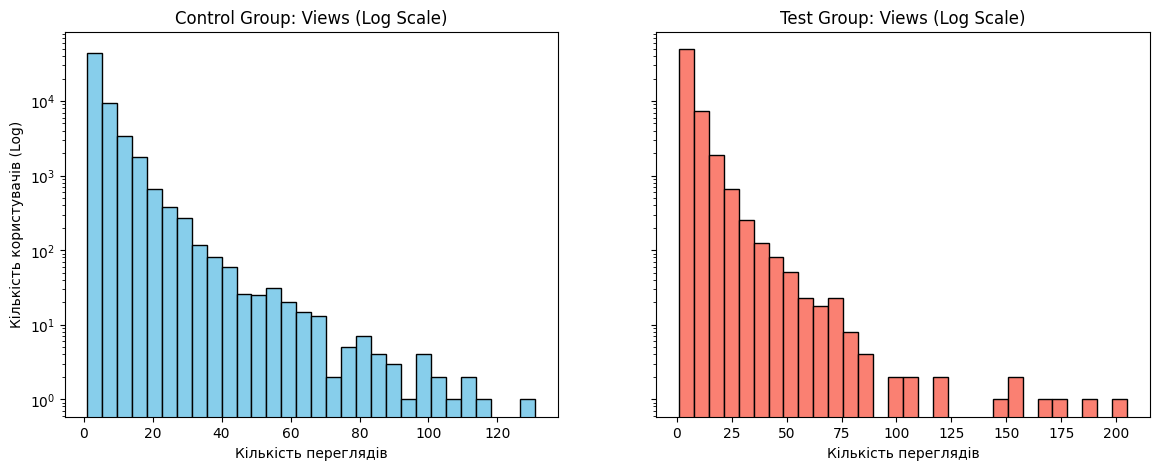

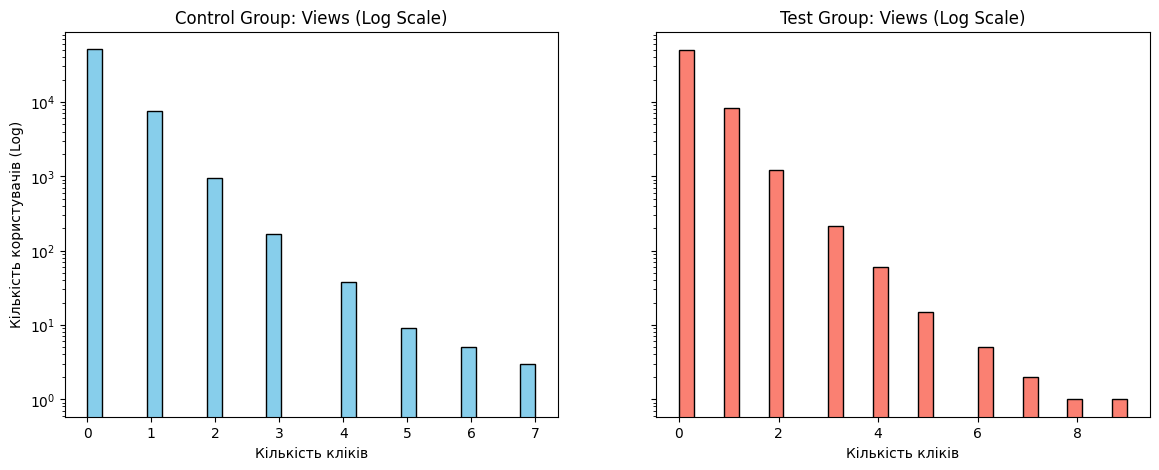

In [9]:
control_norm = data_control['views'].value_counts(bins=10)
test_norm = data_test['views'].value_counts(bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(data_control['views'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_yscale('log')  # ВКЛЮЧАЕМ ЛОГАРИФМИЧЕСКУЮ ШКАЛУ
axes[0].set_title('Control Group: Views (Log Scale)')
axes[0].set_xlabel('Кількість переглядів')
axes[0].set_ylabel('Кількість користувачів (Log)')

axes[1].hist(data_test['views'], bins=30, color='salmon', edgecolor='black')
axes[1].set_yscale('log')  # ВКЛЮЧАЕМ ЛОГАРИФМИЧЕСКУЮ ШКАЛУ
axes[1].set_title('Test Group: Views (Log Scale)')
axes[1].set_xlabel('Кількість переглядів')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(data_control['clicks'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_yscale('log')  # ВКЛЮЧАЕМ ЛОГАРИФМИЧЕСКУЮ ШКАЛУ
axes[0].set_title('Control Group: Views (Log Scale)')
axes[0].set_xlabel('Кількість кліків')
axes[0].set_ylabel('Кількість користувачів (Log)')

axes[1].hist(data_test['clicks'], bins=30, color='salmon', edgecolor='black')
axes[1].set_yscale('log')  # ВКЛЮЧАЕМ ЛОГАРИФМИЧЕСКУЮ ШКАЛУ
axes[1].set_title('Test Group: Views (Log Scale)')
axes[1].set_xlabel('Кількість кліків')
plt.show()

Судячи з графіків очевидно, що розподіл не є нормальним.

Буду використовувати критерій Манна-Вітні.
Формула:

U1 = R_1-(n_1*(n_1+1))/2
U2 = R_2-(n_2*(n_2+1))/2

n_1, n_2 - розмір вибірки
R_1, R_2 - сума рангів користувачів, кожної групи

In [11]:
n_1 = data_control['user_id'].count()
n_2 = data_test['user_id'].count()
data_copy['ctr'] = data_copy['clicks']/data_copy['views']
data_copy = data_copy.sort_values(by='ctr').reset_index(drop=True)
data_copy['rank'] = data_copy['ctr'].rank(method='average')

data_control = data_copy[data_copy['group'] == 'control']
data_test = data_copy[data_copy['group'] == 'test']

R_1 = data_control['rank'].sum()
R_2 = data_test['rank'].sum()

U_1 = R_1-(n_1*(n_1+1))/2
U_2 = R_2-(n_2*(n_2+1))/2

U_stat = min(U_1, U_2)
print(f'U_stat: {U_stat}')

U_stat: 1773003355.0


Далі переходимо до z-test

Мат. очікування = (n_1*n_2)/2

стандартне відхилення = (n_1*n_2*(n_2+n_1+1)/12)**0,5

Z = (U_stat-mu_u)/sigma_u

In [15]:
mu_u = (n_1*n_2)/2
sigma_u = (n_1*n_2*(n_1+n_2+1)/12)**0.5
z = abs((U_stat-mu_u)/sigma_u)

z_critical = 1.96
alpha = 0.05

print(f"Сума рангів Control (R_1): {R_1}")
print(f"Сума рангів Test (R_2): {R_2}")
print(f"Статистика U-критерія: {U_stat}")
print(f"Розрахункове Z-значення: {z:.4f}")
print(f"Критичне значення Z: {z_critical}")

Сума рангів Control (R_1): 3573033355.0
Сума рангів Test (R_2): 3627026645.0
Статистика U-критерія: 1773003355.0
Розрахункове Z-значення: 4.4994
Критичне значення Z: 1.96


Судячи за даними розрахункове значення Z значно більше від критичного значення Z, тобто різниця між двома групами статистично значуща.
Зроблю перевірку через спеціальну бібліотеку.

In [17]:
ctr_control = data_control['ctr']
ctr_test = data_test['ctr']

style_res = stats.mannwhitneyu(ctr_control, ctr_test, alternative='two-sided')
print(f"Статистика U (scipy): {style_res.statistic}")
print(f"Точне p-value (scipy): {style_res.pvalue}")

Статистика U (scipy): 1773003355.0
Точне p-value (scipy): 8.258019361570171e-13


In [19]:
CTR_effect = round((CTR_test-CTR_control)/CTR_control*100, 1)

print(f'Приріст CTR в тестовій групі по відношенню до контрольної: {CTR_effect}%')

Приріст CTR в тестовій групі по відношенню до контрольної: 11.0%


Висновок: Судячи з даних різниця конверсії між тестовою та контрольною групою є статистично значущою 
p-value=8.258019361570171e-13.
Оскільки SRM не виявлено (χ²=0, p=1), рандомізація коректна, тому результатам тесту Манна-Вітні можна довіряти.
А приріст конверсії у тестовій групі по відношенню до контрольної становить 11%.
Можно рекомендувати для використання саме тестовий варіант.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fac373cd-7d8c-46f5-8846-48e72ddf6678' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>